# 编程语言

解释器的原理就是通过树形递归，其输入是另一个程序

机器语言：语句直接由硬件执行（CPU）<br>
高级语言：解释是由另一个程序解释运行，编译是转换为其他语言（如机器语言）

某些语言有特定功能，Erlang用于并发连接

# 示例：计算器

一个非常简单的解释器，只能做加减乘除运算<br>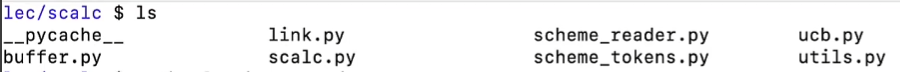

此处的scheme_reader.py就是读取scheme语句转化为链表(python) ......

# 解释Scheme(Proj)

两个主要函数Eval和Apply<br>
其中Eval函数处理基础表达式（其求值就是其本身），调用表达式（用运算符组合来组合参数进行求值）。后者则需要Apply函数具体实现

Eval
``` 
Base cases:
 Primitive values (numbers)
 Look up values bound to symbols

Recursive calls:
 Eval(operator, operands) of call expr
 Apply(procedure, arguments)
 Eval(sub-expr) of special forms
```
Apply
```
Base cases:
 Built-in primitive procedures

Recursive calls:
 Eval(body) of user-defined procedures
```

# 特殊形式处理

之前的计算器只区分数字和调用表达式，但是Scheme里还有特殊形式

特殊形式只需要看list的第一个元素

`(<operator> <operand 0> ......)`综合起来说如果`<operator>`是if之类的特殊形式，我们就特殊处理，如果是lambda或者define之类的，这就是调用表达式，我们就要对`<operator>`求值

In [1]:
(define (demo s)
  (if (null? s)
      '(3)
      (cons (car s) (demo (cdr s)))
      )
  )

In [2]:
(demo '(1 2 3))

(1 2 3 3)

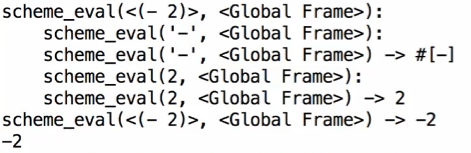

# 逻辑特殊形式

对于if表达式`(if <predicate> <consequent> <alternative>)`的值来说：<br>
1. 计算(evaluate)predicate
2. 选择子表达式
3. 用子表达式代替整个表达式，求值<br>

1.2.用do_if_form处理<br>
3.就是scheme_eval处理了

# Quotation

quote可以把任何表达式变成数据

In [3]:
(quote (+ 1 2))

(+ 1 2)

类似于AI-agent了

# Lambda表达式

对Lambda表达式求值得到一个新函数

```python
class LambdaProcedure:
    def __init__(self, formals, body, env):
        self.formals = formals
        self.body = body
        self.env = env
```

env就是一条Frame链表，每个Frame记录了内部的Binding以及Parent Frame。其中Frames是Python实例，有方法：look up以及define<br>
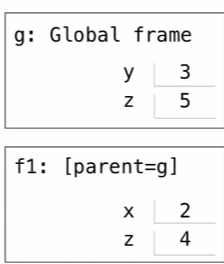

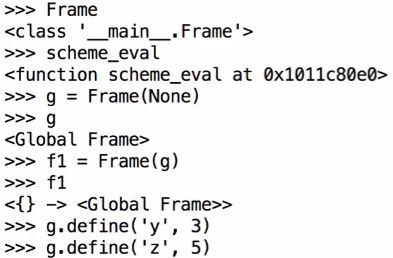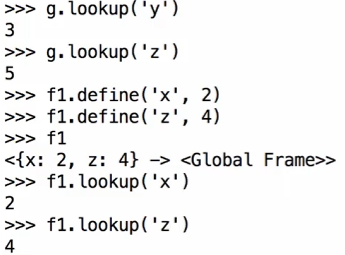

# Define表达式

define 会把变量绑定（a symbol to a value）到当前环境的第一个 frame（当前 frame）中

对于表达式：`(define <name> <expr>)`
1. eval `<expr>`
2. 在当前Frame中，把`<name>`绑定到对应的值上

```python
f = lambda x: x*x

def f(x):
    return x*x
```
对应到Scheme里，他们是等价的，所以我们把define过程当成define`<name>`到一个Lambda表达式上

当调用一个用户定义的函数时，需要创建一个新的 frame，其中形参绑定到实参值，并且 这个 frame 的父环境是该函数定义时的 environment

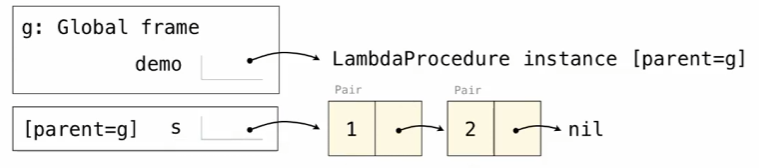

# 动态作用域(Scope)

Lexical(Static) Scope：Parent-Frame是过程被**定义**的环境<br>
Dynamic Scope：Parent-Frame是过程被**调用**的环境

In [4]:
(define f (lambda (x) (+ x y))) ;x是需要输入绑定的，但是y不是，他是调用f环境绑定的
(define g (lambda (x y) (f (+ x x))))

In [8]:
(g 3 7) ;Lexical作用域
;如果是动态作用域则返回13


Traceback (most recent call last):
  File "In [8]", line 1, col 1, in 'g'
  File "In [4]", line 2, col 25, in 'f'
  File "In [4]", line 1, col 28
RunTimeError: unbound variable 'y'

